# NB3 — Seismic + Horizon Import & QC (REVISED)

## Tujuan
Load Near/Mid/Far SEGY partial stacks, windowing per-trace berbasis horizon,
normalisasi amplitude, dan build cube array untuk NB5 (LFM) dan NB6 (inversi).

## Input
- SEGY: Near / Mid / Far partial angle stacks
- Horizon file: HRS v1.1 multi-horizon ASCII
- `CFG.pkl` dari NB1

## Output (`pipeline_data/03_seismic/`)
- `SEIS_CUBE.npz` — cube near/mid/far/full (NTR × NT_WIN)
- `MASK.npz` — boolean valid mask (NTR × NT_WIN)
- `twt_win.npz` — TWT axis (s)
- `trace_axis_inv.npz` — trace index array
- `horizons.pkl` — dict {name: TWT_per_trace (s)}
- `seismic_meta.json` — ringkasan dimensi
- `SN_map.npz` — signal-to-noise per trace (untuk diagnostik NB6)

## Perbaikan dari versi lama
- **BUG FIX**: `save_npy` → `save_npz` (PipelineIO tidak punya save_npy)
- **Horizon matching**: fuzzy column name lookup untuk TOP/BOT_HORIZON
- **QC Plot**: gunakan `plot_utils.plot_seismic_section` + subplot amplitude spectrum
- **S/N diagnostic**: simple estimate dari noise zone di atas reservoir


## Cell 1 — Imports + Load CFG

In [12]:
import sys, warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as ss

sys.path.insert(0, str(Path.cwd()))
from pipeline_io import PipelineIO
import plot_utils

try:
    from obspy import read as obspy_read
    HAS_OBSPY = True
except ImportError:
    HAS_OBSPY = False
    print("[WARN] obspy tidak terinstall — akan pakai simulator")

warnings.filterwarnings("ignore")
np.random.seed(42)

print("=" * 72)
print("  NB3 — SEISMIC + HORIZON IMPORT")
print("=" * 72)

io_in = PipelineIO(stage="01_well_qc")
CFG   = io_in.load_pkl("CFG")

DT           = CFG["seismic_1d"]["dt_s"]
WELL_CFGS    = CFG["wells"]
USE_HORIZON  = CFG["horizon"]["USE"]
TOP_HORIZON  = CFG["horizon"]["TOP_HORIZON"]
BOT_HORIZON  = CFG["horizon"]["BOT_HORIZON"]
PADDING_MS   = CFG["horizon"]["PADDING_MS"]
HORIZON_NULL = CFG["horizon"]["NULL_VAL"]
HORIZON_STYL = CFG["horizon"]["STYLES"]
TOP_TWT      = CFG["seismic_2d"]["TOP_TWT"]
BOTTOM_TWT   = CFG["seismic_2d"]["BOTTOM_TWT"]
TRACE_MIN    = CFG["seismic_2d"]["TRACE_MIN"]
TRACE_MAX    = CFG["seismic_2d"]["TRACE_MAX"]
THETA        = np.array(CFG["inversion_2d"]["theta_deg"], dtype=float)

def normalize_trace(s):
    mx = np.abs(s).max()
    return s / mx if mx > 0 else s

def dbg_array(name, arr, units=""):
    arr = np.asarray(arr)
    nan_n  = int(np.isnan(arr).sum()) if arr.dtype.kind == "f" else 0
    finite = arr[np.isfinite(arr)]    if arr.dtype.kind == "f" else arr
    if finite.size == 0:
        print(f"  [DBG] {name:20s} ALL-NaN"); return
    print(f"  [DBG] {name:20s} shape={str(arr.shape):<14s} "
          f"min={float(finite.min()):>10.4g}  max={float(finite.max()):>10.4g}  "
          f"nan={nan_n}/{arr.size}  {units}")

print(f"  TOP_TWT={TOP_TWT}  BOTTOM_TWT={BOTTOM_TWT}  dt={DT*1000:.1f} ms")
print(f"  Horizon-guided cut: {USE_HORIZON}  (TOP={TOP_HORIZON}, BOT={BOT_HORIZON})")
print("  ✓ CFG loaded")


  NB3 — SEISMIC + HORIZON IMPORT
  TOP_TWT=2000.0  BOTTOM_TWT=4000.0  dt=4.0 ms
  Horizon-guided cut: True  (TOP=Montara, BOT=Nome)
  ✓ CFG loaded


## Cell 2 — SEGY Loader + Simulator

In [13]:
def load_segy_stack(path):
    if not HAS_OBSPY or not Path(path).exists():
        raise FileNotFoundError(f"SEGY not available: {path}")
    st = obspy_read(str(path), format="SEGY")
    n_traces  = len(st)
    n_samples = st[0].stats.npts
    dt_s      = st[0].stats.delta
    A = np.column_stack([st[i].data for i in range(n_traces)])
    return A, dt_s, n_traces, n_samples


def simulate_segy_stack(ntr=1000, nsamp=None, dt=0.002, seed=1, amp_scale=1.0):
    if nsamp is None:
        nsamp = int(BOTTOM_TWT / 1000.0 / dt) + 50
    rng  = np.random.default_rng(seed)
    data = 0.02 * rng.standard_normal((nsamp, ntr)).astype(np.float32) * amp_scale

    t_start = TOP_TWT / 1000.0
    t_end   = BOTTOM_TWT / 1000.0
    for frac, a in zip([0.10, 0.25, 0.40, 0.55, 0.75, 0.90],
                       [0.7, -0.5, 0.6, -0.4, 0.5, -0.35]):
        t_ref = t_start + frac * (t_end - t_start)
        for itr in range(ntr):
            tt  = t_ref + 0.00005 * (itr - ntr / 2)
            idx = int(round(tt / dt))
            if 0 <= idx < nsamp:
                data[idx, itr] += a * amp_scale

    f0 = 35.0
    tw = np.arange(-0.08, 0.08 + dt, dt)
    w  = (1 - 2 * (np.pi * f0 * tw)**2) * np.exp(-(np.pi * f0 * tw)**2)
    data = np.apply_along_axis(lambda x: np.convolve(x, w, mode="same"), 0, data)
    return data.astype(np.float32), dt, ntr, nsamp


print("[CELL 2] SEGY loader ready ✓")


[CELL 2] SEGY loader ready ✓


## Cell 3 — Load Near/Mid/Far SEGY

In [14]:
print("\n" + "=" * 72)
print("  LOADING SEGY")
print("=" * 72)

try:
    A_near, dt_global, n_traces, n_samples = load_segy_stack(CFG["seismic_2d"]["segy_near"])
    A_mid,  _, _, _ = load_segy_stack(CFG["seismic_2d"]["segy_mid"])
    A_far,  _, _, _ = load_segy_stack(CFG["seismic_2d"]["segy_far"])
    print("  [SEGY] Near/Mid/Far loaded from disk ✓")
except Exception as e:
    print(f"  [SEGY] {type(e).__name__}: {e}")
    print(f"  [SEGY] fallback simulator")
    A_near, dt_global, n_traces, n_samples = simulate_segy_stack(seed=2, amp_scale=1.0)
    A_mid,  _, _, _ = simulate_segy_stack(seed=3, amp_scale=1.1)
    A_far,  _, _, _ = simulate_segy_stack(seed=4, amp_scale=1.3)

time_ms   = np.arange(n_samples) * dt_global * 1000.0
trace_idx = np.arange(1, n_traces + 1)

dbg_array("A_near (raw)", A_near, "amp")
dbg_array("A_mid  (raw)", A_mid,  "amp")
dbg_array("A_far  (raw)", A_far,  "amp")
print(f"  Traces  : {n_traces}")
print(f"  Samples : {n_samples}")
print(f"  dt      : {dt_global*1000:.2f} ms")
print(f"  TWT     : {time_ms[0]:.0f} – {time_ms[-1]:.0f} ms")



  LOADING SEGY
  [SEGY] Near/Mid/Far loaded from disk ✓
  [DBG] A_near (raw)         shape=(1501, 895)    min= -1.68e+05  max=  1.38e+05  nan=0/1343395  amp
  [DBG] A_mid  (raw)         shape=(1501, 895)    min=-1.295e+05  max= 1.142e+05  nan=0/1343395  amp
  [DBG] A_far  (raw)         shape=(1501, 895)    min=-1.159e+05  max= 1.022e+05  nan=0/1343395  amp
  Traces  : 895
  Samples : 1501
  dt      : 4.00 ms
  TWT     : 0 – 6000 ms


## Cell 4 — Long-form DataFrame + windowing + per-trace normalization

In [15]:
df_seismic = pd.DataFrame({
    "Near_Amplitude": A_near.flatten(order="F"),
    "Mid_Amplitude" : A_mid.flatten(order="F"),
    "Far_Amplitude" : A_far.flatten(order="F"),
    "Time_ms"       : np.tile(time_ms, n_traces),
    "Trace"         : np.repeat(trace_idx, n_samples),
})
df_seismic = (df_seismic
              .query("@TOP_TWT <= Time_ms <= @BOTTOM_TWT")
              .query("@TRACE_MIN < Trace < @TRACE_MAX")
              .sort_values(["Time_ms","Trace"])
              .reset_index(drop=True))

for col in ["Near_Amplitude","Mid_Amplitude","Far_Amplitude"]:
    df_seismic[col] = df_seismic.groupby("Trace")[col].transform(normalize_trace)

print(f"  Seismic window : {df_seismic['Time_ms'].min():.0f} – "
      f"{df_seismic['Time_ms'].max():.0f} ms")
print(f"  Traces         : {df_seismic['Trace'].nunique()}")
print(f"  Total rows     : {len(df_seismic):,}")


  Seismic window : 2000 – 4000 ms
  Traces         : 895
  Total rows     : 448,395


## Cell 5 — Horizon loader (HRS v1.1 + fuzzy column matching)

**Fix**: Fuzzy matching untuk `TOP_HORIZON` dan `BOT_HORIZON` — toleran terhadap
perbedaan nama kolom antara CFG string dan kolom aktual di file HRS (misalnya
"Montara" vs "Montara_Top" vs "montara").

In [16]:
def _fuzzy_match_col(target, columns):
    """Return column name yang paling cocok dengan target string (case-insensitive)."""
    t = target.lower().strip()
    for c in columns:
        if c.lower().strip() == t:
            return c
    for c in columns:
        if t in c.lower() or c.lower() in t:
            return c
    return None


def load_hampson_russell_horizon(filepath, null_val=HORIZON_NULL):
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"Horizon not found: {filepath}")

    raw   = filepath.read_text(encoding="utf-8", errors="ignore")
    lines = raw.replace("\r\n","\n").replace("\r","\n").splitlines()

    body_idx = next((i for i, ln in enumerate(lines)
                     if ln.lstrip().startswith("#{BODY}")), None)
    if body_idx is None:
        raise ValueError(f"Penanda '#{{BODY}}' tidak ditemukan di: {filepath}")

    h_idx = next((j for j in range(body_idx+1, len(lines))
                  if lines[j].strip() and not lines[j].lstrip().startswith("#")), None)
    if h_idx is None:
        raise ValueError(f"Header kolom tidak ditemukan")

    cols_raw = re.findall(r"<([^>]+)>", lines[h_idx])
    if len(cols_raw) < 3:
        cols_raw = re.split(r"\s{2,}", lines[h_idx].strip())

    columns = []
    for c in cols_raw:
        c = c.strip()
        for pref in ("Domain:","Time:","Depth:"):
            if c.startswith(pref):
                c = c[len(pref):].strip(); break
        columns.append(c)

    rows = []
    for ln in lines[h_idx+1:]:
        s = ln.strip()
        if not s or s.startswith("#"): continue
        parts = re.split(r"\s+", s)
        if len(parts) < 2: continue
        if len(parts) > len(columns):
            parts = parts[:len(columns)]
        elif len(parts) < len(columns):
            parts = parts + [""] * (len(columns)-len(parts))
        rows.append(parts)

    if not rows:
        raise ValueError(f"Tidak ada baris data: {filepath}")

    df = pd.DataFrame(rows, columns=columns)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    null_f = float(null_val)
    for col in df.columns[2:]:
        df[col] = df[col].where(~np.isclose(df[col], null_f, rtol=1e-3), other=np.nan)

    def _safe_col(name):
        name = re.sub(r"[#@$%^&*!?(){}\[\]<>]","",name)
        name = name.strip().replace(" ","_"); name = re.sub(r"_+","_",name).strip("_")
        return name if name else "COL"
    df.columns = [_safe_col(c) for c in df.columns]

    print(f"  [Horizon] {filepath.name}: {len(df)} traces × {len(df.columns)-2} horizons")
    print(f"  Columns : {list(df.columns)}")
    return df


def simulate_horizon_df(trace_idx_arr):
    ntr = len(trace_idx_arr)
    mid = (TOP_TWT + BOTTOM_TWT) / 2
    df  = pd.DataFrame({"Trace": trace_idx_arr, "CDP": trace_idx_arr})
    df["Echuca_Shoals"]    = mid - 350 + 8*np.sin(np.arange(ntr)*0.009)
    df["Jamieson"]         = mid - 350 + 8*np.sin(np.arange(ntr)*0.008)
    df["Montara"]          = mid - 100 + 10*np.sin(np.arange(ntr)*0.010)
    df["Nome"]             = mid + 100 + 10*np.sin(np.arange(ntr)*0.012+1)
    df["Plover_Reservoir"] = mid + 250 +  6*np.sin(np.arange(ntr)*0.007)
    df["Plover_Volcanics"] = mid + 350 +  6*np.sin(np.arange(ntr)*0.007+0.5)
    return df


# ── Load ──────────────────────────────────────────────────────────────────
df_hor_win = None
if USE_HORIZON:
    try:
        df_horizon = load_hampson_russell_horizon(CFG["seismic_2d"]["horizon_file"])
        print("\n  [Horizon] loaded from file ✓")
    except Exception as e:
        print(f"\n  [Horizon] {type(e).__name__}: {e} — fallback simulator")
        df_horizon = simulate_horizon_df(trace_idx)

    # ── Fuzzy match TOP / BOT horizon column names ─────────────────────────
    hor_data_cols = [c for c in df_horizon.columns if c not in ("Trace","CDP")]
    TOP_COL = _fuzzy_match_col(TOP_HORIZON, hor_data_cols)
    BOT_COL = _fuzzy_match_col(BOT_HORIZON, hor_data_cols)

    print(f"\n  [HorizonMatch] TOP_HORIZON='{TOP_HORIZON}' → column='{TOP_COL}'")
    print(f"  [HorizonMatch] BOT_HORIZON='{BOT_HORIZON}' → column='{BOT_COL}'")

    if TOP_COL is None or BOT_COL is None:
        print(f"  [WARN] Satu atau dua horizon tidak ditemukan — "
              f"available: {hor_data_cols}")

    df_hor_win = (df_horizon
                  .query("@TRACE_MIN < Trace < @TRACE_MAX")
                  .reset_index(drop=True))
    print(f"  [Horizon] windowed: {len(df_hor_win)} traces")
else:
    TOP_COL = BOT_COL = None
    print("  USE_HORIZON=False — skip horizon load")


  [Horizon] Arbitary4_horizon.txt: 895 traces × 4 horizons
  Columns : ['Trace', 'CDP', 'Montara', 'Nome', 'Plover_Reservoir', 'Plover_Volcanics']

  [Horizon] loaded from file ✓

  [HorizonMatch] TOP_HORIZON='Montara' → column='Montara'
  [HorizonMatch] BOT_HORIZON='Nome' → column='Nome'
  [Horizon] windowed: 895 traces


## Cell 6 — Horizon-guided cut (per-trace windowing)

In [17]:
def cut_seismic_by_horizon(df_seis_full, df_hor, top_col, bot_col,
                            padding_ms=PADDING_MS):
    df_seis_full = df_seis_full.copy()
    df_seis_full["Time_ms"] = df_seis_full["Time_ms"].round(1)

    trace_common = np.array(sorted(
        set(df_seis_full["Trace"].unique()) & set(df_hor["Trace"].unique())))
    if len(trace_common) == 0:
        raise RuntimeError("No common traces between seismic and horizon.")

    hor_lookup = df_hor.set_index("Trace")
    records = []; info_rows = []
    for tid in trace_common:
        df_tr = df_seis_full[df_seis_full["Trace"] == tid]
        if df_tr.empty: continue
        row   = hor_lookup.loc[tid]
        t_top_h = float(row.get(top_col, np.nan)) if top_col else np.nan
        t_bot_h = float(row.get(bot_col, np.nan)) if bot_col else np.nan
        if np.isnan(t_top_h) or np.isnan(t_bot_h): continue
        t_top = min(t_top_h, t_bot_h) - padding_ms
        t_bot = max(t_top_h, t_bot_h) + padding_ms
        if (t_bot - t_top) < 6.0: continue
        df_c = df_tr[(df_tr["Time_ms"] >= t_top) &
                     (df_tr["Time_ms"] <= t_bot)].copy()
        if df_c.empty: continue
        records.append(df_c)
        info_rows.append({"Trace": int(tid), "TWT_top": t_top,
                          "TWT_bottom": t_bot, "n_samples": len(df_c)})
    if not records:
        raise RuntimeError("Empty cut result — check horizon coverage.")
    df_cut   = pd.concat(records, ignore_index=True)
    cut_info = pd.DataFrame(info_rows)
    print(f"  [HorizonCut] {cut_info['Trace'].nunique()} traces cut | "
          f"samples/trace ~{cut_info['n_samples'].median():.0f}")
    return df_cut, cut_info


df_seismic_for_inversion = df_seismic
cut_info = None

if USE_HORIZON and TOP_COL and BOT_COL and df_hor_win is not None:
    try:
        df_seismic_cut, cut_info = cut_seismic_by_horizon(
            df_seismic, df_hor_win, TOP_COL, BOT_COL)
        df_seismic_for_inversion = df_seismic_cut
        print(f"  [HorizonCut] TWT range after cut: "
              f"{df_seismic_cut['Time_ms'].min():.0f} – "
              f"{df_seismic_cut['Time_ms'].max():.0f} ms")
    except Exception as e:
        print(f"  [WARN] horizon cut failed ({e}) — using full TWT window")
else:
    print("  [HorizonCut] skipped — using full TWT window")


  [HorizonCut] 895 traces cut | samples/trace ~57
  [HorizonCut] TWT range after cut: 3000 – 3452 ms


## Cell 7 — Build seismic cube arrays + horizons dict

In [18]:
trace_axis_inv = np.sort(df_seismic_for_inversion["Trace"].unique())
NTR = len(trace_axis_inv)

t_min = df_seismic_for_inversion["Time_ms"].min()
t_max = df_seismic_for_inversion["Time_ms"].max()

twt_win_ms = np.arange(t_min, t_max + 0.5*dt_global*1000, dt_global*1000)
twt_win    = twt_win_ms / 1000.0
NT_WIN     = len(twt_win)
DT_SEIS    = float(dt_global)

def _reshape_angle(col):
    arr = np.full((NTR, NT_WIN), np.nan, dtype=np.float32)
    piv = (df_seismic_for_inversion
           .pivot_table(index="Trace", columns="Time_ms",
                        values=col, aggfunc="first")
           .reindex(index=trace_axis_inv, columns=twt_win_ms))
    arr[:] = piv.values.astype(np.float32)
    return arr

seis_win = {"near": _reshape_angle("Near_Amplitude"),
            "mid" : _reshape_angle("Mid_Amplitude"),
            "far" : _reshape_angle("Far_Amplitude")}
seis_win["full"] = (seis_win["near"] + seis_win["mid"] + seis_win["far"]) / 3.0

MASK = np.isfinite(seis_win["near"])
for key in seis_win:
    seis_win[key] = np.nan_to_num(seis_win[key], nan=0.0)

# Horizons dict (name → TWT-seconds per trace)
horizons = {}
if df_hor_win is not None:
    for col in [c for c in df_hor_win.columns if c not in ("Trace","CDP")]:
        ser = (df_hor_win.set_index("Trace")[col]
               .reindex(trace_axis_inv)
               .interpolate(limit_direction="both")
               .values) / 1000.0
        horizons[col] = ser

print(f"  seis_win shape : {seis_win['near'].shape}")
print(f"  twt_win (s)    : {twt_win[0]:.3f} – {twt_win[-1]:.3f}")
print(f"  NTR={NTR}  NT_WIN={NT_WIN}  DT_SEIS={DT_SEIS*1000:.1f} ms")
print(f"  MASK valid     : {MASK.sum():,} / {MASK.size:,} ({MASK.mean()*100:.1f}%)")
print(f"  horizons       : {list(horizons.keys())}")


  seis_win shape : (895, 114)
  twt_win (s)    : 3.000 – 3.452
  NTR=895  NT_WIN=114  DT_SEIS=4.0 ms
  MASK valid     : 52,521 / 102,030 (51.5%)
  horizons       : ['Montara', 'Nome', 'Plover_Reservoir', 'Plover_Volcanics']


## Cell 8 — QC: Amplitude spectrum per angle stack

Verifikasi bahwa bandwidth seismik konsisten antar angle dan mencakup frekuensi
yang diperlukan inversi (>10 Hz). Dominan frequency dan bandwidth dicetak untuk
kalibrasi wavelet di NB4.


  QC: AMPLITUDE SPECTRUM PER ANGLE
  Near : f_dominant=21.9 Hz  bandwidth_-6dB=41.7 Hz
  Mid  : f_dominant=15.4 Hz  bandwidth_-6dB=32.9 Hz
  Far  : f_dominant=15.4 Hz  bandwidth_-6dB=17.5 Hz


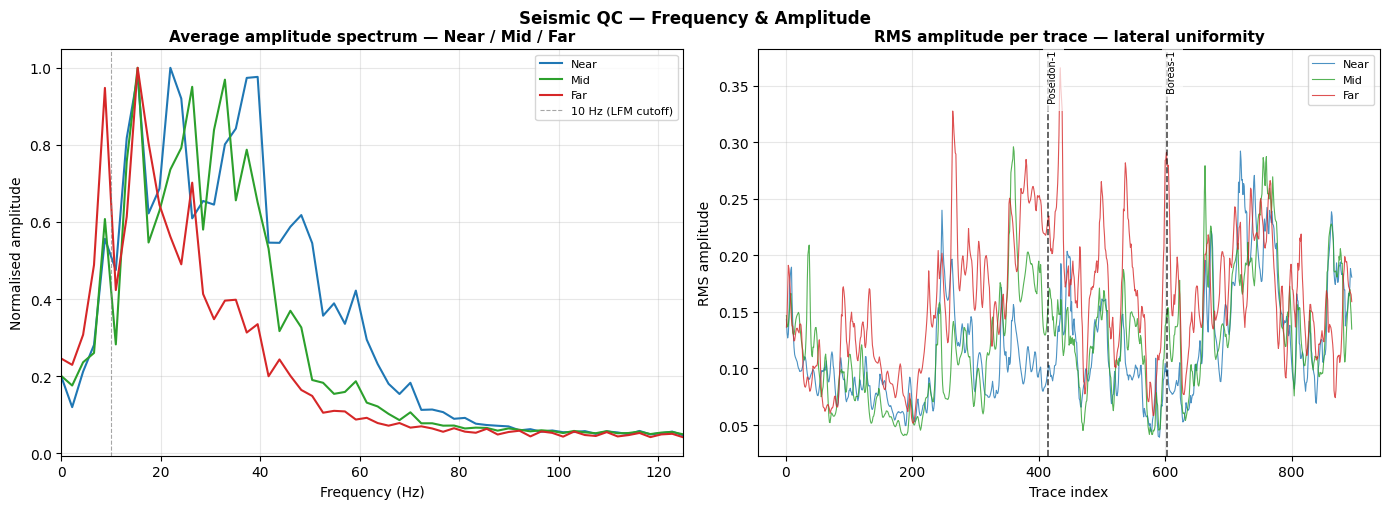

In [19]:
print("\n" + "=" * 72)
print("  QC: AMPLITUDE SPECTRUM PER ANGLE")
print("=" * 72)

angle_names = ["Near", "Mid", "Far"]
angle_cubes = [seis_win["near"], seis_win["mid"], seis_win["far"]]
colors_spec  = ["#1f77b4", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel kiri: average amplitude spectrum ──
ax = axes[0]
for name, cube, color in zip(angle_names, angle_cubes, colors_spec):
    # Average power spectrum per trace, convert to amplitude spectrum
    ps_traces = []
    for itr in range(min(NTR, 200)):  # sample 200 traces for speed
        tr = cube[itr, :]
        if np.any(tr != 0):
            ps = np.abs(np.fft.rfft(tr))**2
            ps_traces.append(ps)
    if ps_traces:
        mean_ps = np.mean(ps_traces, axis=0)
        freqs   = np.fft.rfftfreq(NT_WIN, d=DT_SEIS)
        amp_spec = np.sqrt(mean_ps)
        amp_spec /= (amp_spec.max() + 1e-12)
        ax.plot(freqs, amp_spec, color=color, lw=1.5, label=name)
        f_dom = freqs[np.argmax(amp_spec)]
        # bandwidth: -6dB point
        thresh = amp_spec.max() * 0.5
        f_above = freqs[amp_spec >= thresh]
        bw = f_above[-1] - f_above[0] if len(f_above) > 1 else 0
        print(f"  {name:5s}: f_dominant={f_dom:.1f} Hz  bandwidth_-6dB={bw:.1f} Hz")

ax.set_xlabel("Frequency (Hz)", fontsize=10)
ax.set_ylabel("Normalised amplitude", fontsize=10)
ax.set_title("Average amplitude spectrum — Near / Mid / Far", fontsize=11, fontweight="bold")
ax.axvline(10, color="gray", lw=0.8, ls="--", alpha=0.7, label="10 Hz (LFM cutoff)")
ax.set_xlim(0, 1/(2*DT_SEIS))
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Panel kanan: envelope RMS vs trace ──
ax = axes[1]
for name, cube, color in zip(angle_names, angle_cubes, colors_spec):
    rms_per_trace = np.sqrt(np.mean(cube**2, axis=1))
    ax.plot(trace_axis_inv, rms_per_trace, color=color, lw=0.8, alpha=0.8, label=name)

# Well positions
for wname, wcfg in WELL_CFGS.items():
    ax.axvline(wcfg["trace_idx"], color="black", lw=1.2, ls="--", alpha=0.7)
    ax.text(wcfg["trace_idx"], ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 0.1,
            f" {wname}", fontsize=7, rotation=90, va="top",
            bbox=dict(fc="white", alpha=0.7, lw=0))

ax.set_xlabel("Trace index", fontsize=10)
ax.set_ylabel("RMS amplitude", fontsize=10)
ax.set_title("RMS amplitude per trace — lateral uniformity", fontsize=11, fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Seismic QC — Frequency & Amplitude", fontsize=12, fontweight="bold", y=1.01)
plt.show()


## Cell 9 — S/N diagnostic per trace

  S/N statistics (dB):
    Near : median=+220.1  P10=+2.0  P90=+231.7
    Mid  : median=+221.8  P10=+7.3  P90=+231.1
    Far  : median=+225.0  P10=+7.4  P90=+231.5


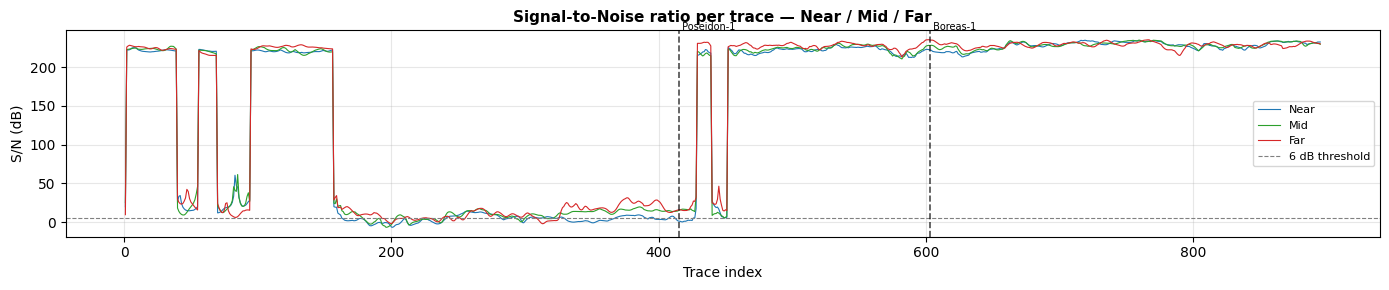

In [20]:
# Estimate S/N ratio: 
# Signal zone = around reservoir (middle 30% of TWT window)
# Noise zone  = top 20% of TWT window (pre-Montara)
n_noise = max(5, int(0.20 * NT_WIN))
n_sig   = max(5, int(0.15 * NT_WIN))
sig_start = NT_WIN // 2 - n_sig // 2
sig_end   = sig_start + n_sig

SN_MAP = np.full((NTR, 3), np.nan)
for i_a, cube in enumerate([seis_win["near"], seis_win["mid"], seis_win["far"]]):
    for itr in range(NTR):
        tr     = cube[itr, :]
        noise  = tr[:n_noise]
        signal = tr[sig_start:sig_end]
        rms_n  = np.sqrt(np.mean(noise**2)) + 1e-12
        rms_s  = np.sqrt(np.mean(signal**2))
        SN_MAP[itr, i_a] = 20 * np.log10(rms_s / rms_n)

print("  S/N statistics (dB):")
for i_a, name in enumerate(["Near","Mid","Far"]):
    sn = SN_MAP[:, i_a]
    print(f"    {name:5s}: median={np.nanmedian(sn):+.1f}  "
          f"P10={np.nanpercentile(sn,10):+.1f}  P90={np.nanpercentile(sn,90):+.1f}")

# Quick plot
fig, ax = plt.subplots(figsize=(14, 3))
for i_a, (name, color) in enumerate(zip(["Near","Mid","Far"],["#1f77b4","#2ca02c","#d62728"])):
    ax.plot(trace_axis_inv, SN_MAP[:, i_a], color=color, lw=0.8, label=name)
ax.axhline(6, color="gray", lw=0.8, ls="--", label="6 dB threshold")
for wname, wcfg in WELL_CFGS.items():
    ax.axvline(wcfg["trace_idx"], color="black", lw=1.2, ls="--", alpha=0.7)
    ax.text(wcfg["trace_idx"], ax.get_ylim()[1] if ax.get_ylim() != (0,1) else 20,
            f" {wname}", fontsize=7)
ax.set_xlabel("Trace index", fontsize=10)
ax.set_ylabel("S/N (dB)", fontsize=10)
ax.set_title("Signal-to-Noise ratio per trace — Near / Mid / Far", fontsize=11, fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Cell 10 — QC plot: seismic section Near/Mid/Far + horizon overlay

Menggunakan `plot_utils.plot_seismic_section` dengan horizon overlay + well markers.

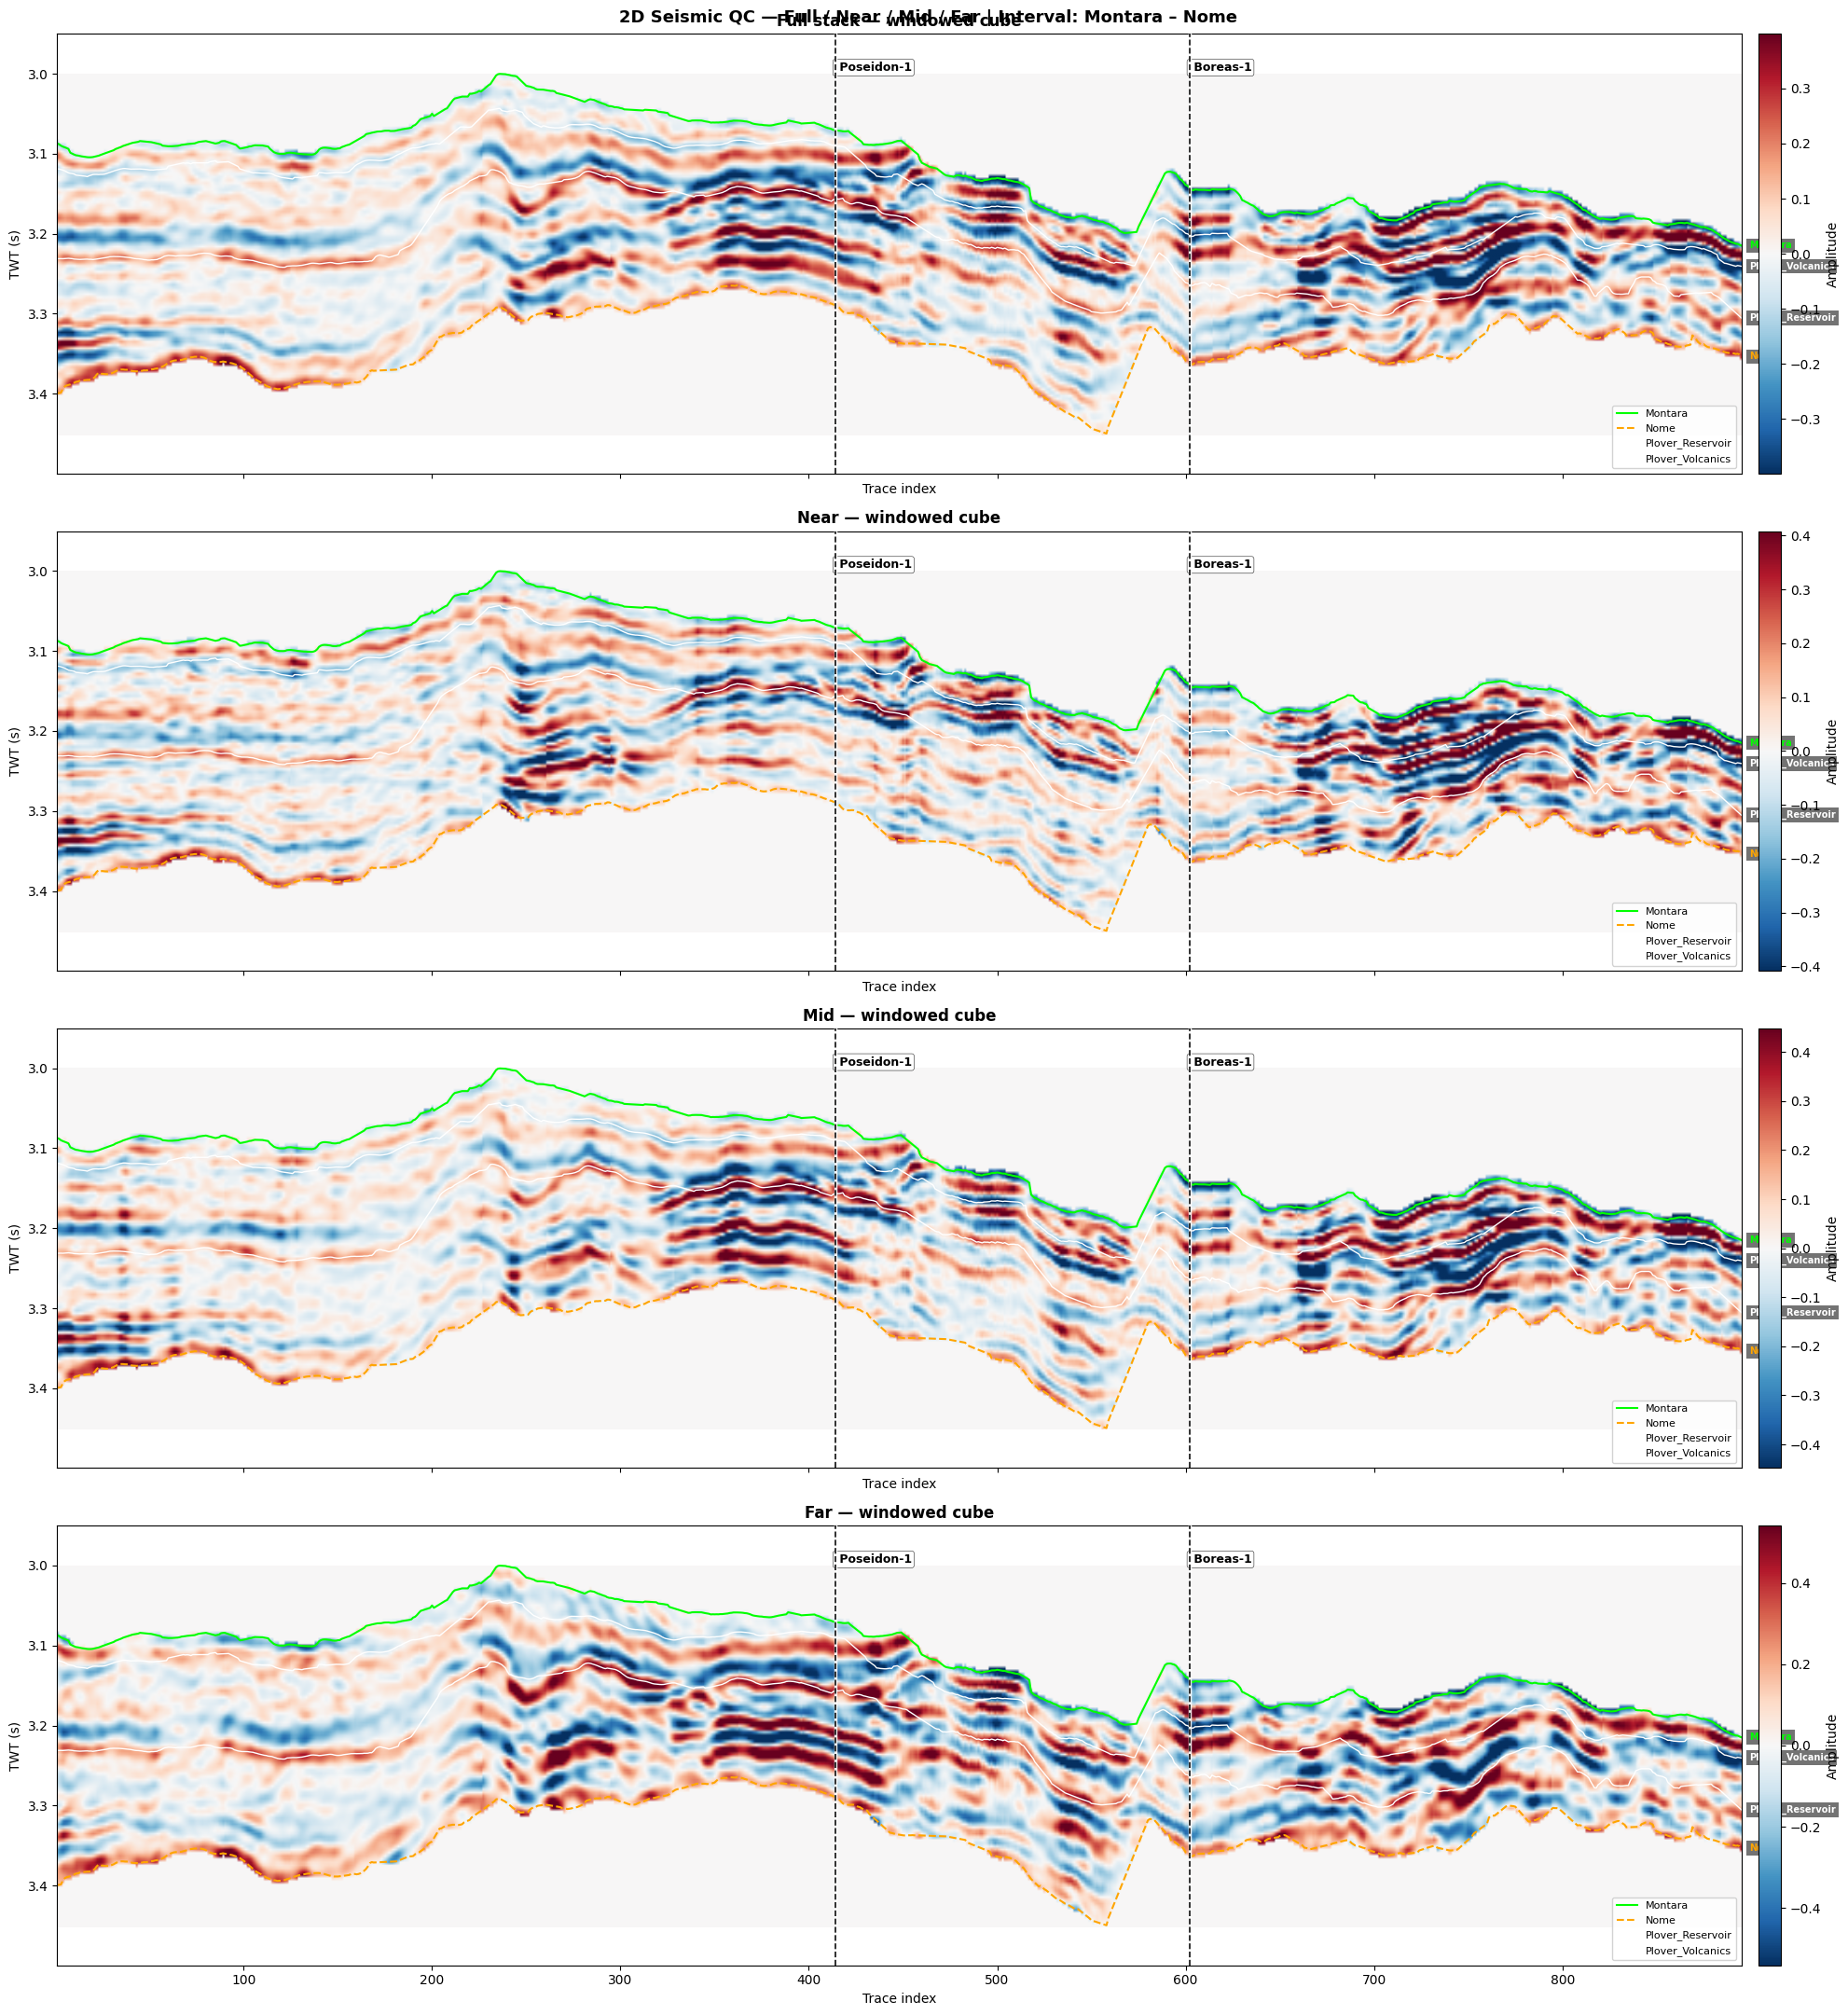

In [21]:
# ── Bounding TWT dari horizon Montara / Nome ─────────────────────────────
top_col_plot = _fuzzy_match_col("Montara", list(horizons.keys()))
bot_col_plot = _fuzzy_match_col("Nome",    list(horizons.keys()))
twt_top_plot = float(np.nanmin(horizons[top_col_plot])) - 0.05 if top_col_plot else twt_win[0]
twt_bot_plot = float(np.nanmax(horizons[bot_col_plot])) + 0.05 if bot_col_plot else twt_win[-1]

# Horizon styles (fallback to default)
hor_styles_plot = {}
for hname, hz in horizons.items():
    sty = HORIZON_STYL.get(hname, {"color":"white","lw":1.0,"ls":"-"})
    hor_styles_plot[hname] = sty

# Well trace indices (dalam ruang trace_axis_inv)
well_trace_map = {}
for wname, wcfg in WELL_CFGS.items():
    i_arr = np.where(np.isclose(trace_axis_inv, wcfg["trace_idx"]))[0]
    well_trace_map[wname] = int(i_arr[0]) if i_arr.size else int(
        np.argmin(np.abs(trace_axis_inv - wcfg["trace_idx"])))

fig, axes = plt.subplots(4, 1, figsize=(20, 22), sharex=True)
panel_names  = ["Full stack", "Near", "Mid", "Far"]
panel_cubes  = [seis_win["full"], seis_win["near"],
                seis_win["mid"],  seis_win["far"]]
panel_colors = ["RdBu_r","RdBu_r","RdBu_r","RdBu_r"]

for ax, name, cube, cmap in zip(axes, panel_names, panel_cubes, panel_colors):
    plot_utils.plot_seismic_section(
        cube, twt_win, trace_axis_inv,
        title=f"{name} — windowed cube",
        horizons=horizons,
        horizon_styles=hor_styles_plot,
        well_traces=well_trace_map,
        cmap=cmap, cbar_label="Amplitude",
        ax=ax, show=False,
    )
    ax.set_ylim(twt_bot_plot, twt_top_plot)

    # Annotate horizon names di sisi kanan
    for hname, hz in horizons.items():
        valid = hz[np.isfinite(hz)]
        if len(valid):
            sty = hor_styles_plot.get(hname, {})
            ax.annotate(hname,
                        xy=(trace_axis_inv[-1], hz[-1]),
                        xytext=(6, 0), textcoords="offset points",
                        fontsize=7, fontweight="bold",
                        color=sty.get("color","white"), va="center", ha="left",
                        bbox=dict(fc="black", alpha=0.55, pad=2, ec="none"),
                        annotation_clip=False)

fig.suptitle("2D Seismic QC — Full / Near / Mid / Far | Interval: Montara – Nome",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## Cell 11 — Save outputs untuk NB4+

In [22]:
io_out = PipelineIO(stage="03_seismic")

# ── Cube (P1 BUG FIX: pakai save_npz bukan save_npy) ──
io_out.save_npz("SEIS_CUBE",
                near=seis_win["near"].astype(np.float32),
                mid =seis_win["mid"].astype(np.float32),
                far =seis_win["far"].astype(np.float32),
                full=seis_win["full"].astype(np.float32))

io_out.save_npz("MASK",          mask=MASK.astype(np.uint8))
io_out.save_npz("twt_win",       twt_win=twt_win.astype(np.float64))
io_out.save_npz("trace_axis_inv",trace_axis_inv=trace_axis_inv.astype(np.float64))
io_out.save_npz("SN_map",        sn_map=SN_MAP.astype(np.float32))

# Horizons + DataFrames
io_out.save_pkl("horizons", horizons)
io_out.save_df("df_seismic_for_inversion", df_seismic_for_inversion)
if df_hor_win is not None:
    io_out.save_df("df_hor_win", df_hor_win)

# Meta (tambahkan TOP_COL / BOT_COL yang sudah di-resolve)
io_out.save_json("seismic_meta", {
    "NTR"          : int(NTR),
    "NT_WIN"       : int(NT_WIN),
    "DT_SEIS"      : float(DT_SEIS),
    "twt_win_s"    : [float(twt_win[0]), float(twt_win[-1])],
    "trace_min"    : int(trace_axis_inv.min()),
    "trace_max"    : int(trace_axis_inv.max()),
    "horizons"     : list(horizons.keys()),
    "TOP_COL"      : TOP_COL,
    "BOT_COL"      : BOT_COL,
    "use_horizon_cut": bool(USE_HORIZON),
    "SN_median_dB" : {
        "near": float(np.nanmedian(SN_MAP[:,0])),
        "mid" : float(np.nanmedian(SN_MAP[:,1])),
        "far" : float(np.nanmedian(SN_MAP[:,2])),
    },
})

io_out.list_files()
print("\n" + "=" * 72)
print("  ✓ NB3 selesai — siap lanjut ke NB4 (Well-to-Seismic Tie)")
print("=" * 72)


  [03_seismic] 11 file(s) di pipeline_data\03_seismic:
    • df_hor_win.csv                                40.6 KB
    • df_hor_win.parquet                            35.0 KB
    • df_seismic_for_inversion.csv                2410.8 KB
    • df_seismic_for_inversion.parquet             906.5 KB
    • horizons.pkl                                  28.2 KB
    • MASK.npz                                       1.4 KB
    • SEIS_CUBE.npz                                763.1 KB
    • seismic_meta.json                              0.4 KB
    • SN_map.npz                                     9.4 KB
    • trace_axis_inv.npz                             1.4 KB
    • twt_win.npz                                    0.8 KB

  ✓ NB3 selesai — siap lanjut ke NB4 (Well-to-Seismic Tie)
